# **House Price Prediction using Regression**

# **Problem Statement**

The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.

# **Objectives**
The objective of this task is to:
● Understand and explore the housing dataset.
● Perform data preprocessing including handling missing values, duplicates, and outliers.
● Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the
data.
● Apply encoding, log transformation, and feature scaling where necessary.
● Train multiple regression algorithms to predict house prices.
● Evaluate and compare model performance using appropriate evaluation metrics.

# **Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load the Dataset**

In [ ]:
data=pd.read_csv("house_price_regression_dataset.csv")
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


# **Check Dataset**

In [ ]:
data.shape

(1000, 8)

In [ ]:
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
data.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [ ]:
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [ ]:
data.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


In [ ]:
# num_cols
num_cols = data.select_dtypes(include=['float64','int64'])
num_cols

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [ ]:
# num_cols
cat_cols = data.select_dtypes(include=['object'])
cat_cols

""
0
1
2
3
4
...
995
996
997
998


# Handle Missing Values

In [ ]:
data.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


# Remove Duplicate Records

In [ ]:
data.duplicated().sum()

np.int64(0)

# Univariate Analysis

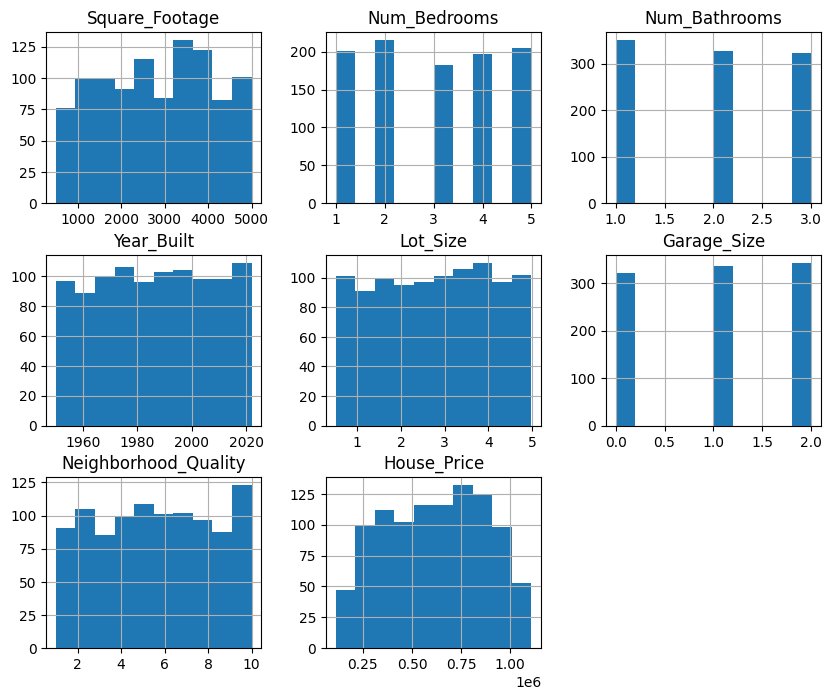

In [ ]:

data.hist(figsize=(10,8))
plt.show()


#  Bivariate Analysis

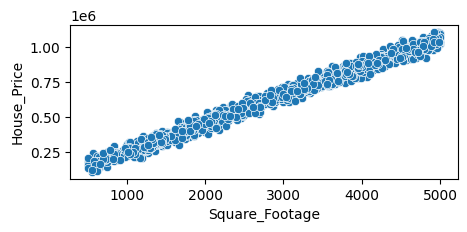

In [ ]:
plt.figure(figsize=(5,2))
sns.scatterplot(x="Square_Footage", y="House_Price", data=data)
plt.show()

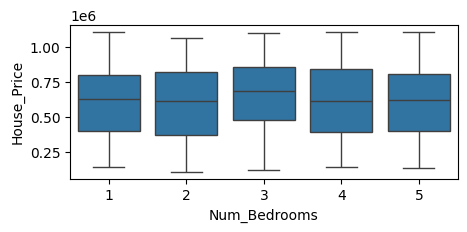

In [ ]:
plt.figure(figsize=(5,2))
sns.boxplot(x="Num_Bedrooms", y="House_Price", data=data)
plt.show()

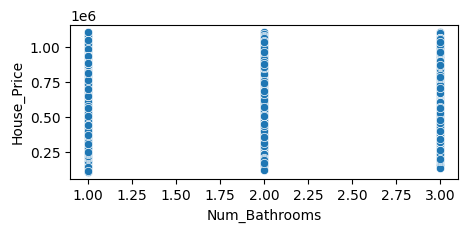

In [ ]:
plt.figure(figsize=(5,2))
sns.scatterplot(x="Num_Bathrooms", y="House_Price", data=data)
plt.show()

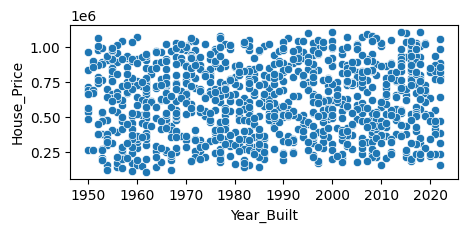

In [ ]:
plt.figure(figsize=(5,2))
sns.scatterplot(x="Year_Built", y="House_Price", data=data)
plt.show()

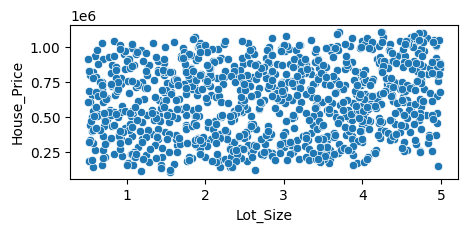

In [ ]:
plt.figure(figsize=(5,2))
sns.scatterplot(x="Lot_Size", y="House_Price", data=data)
plt.show()

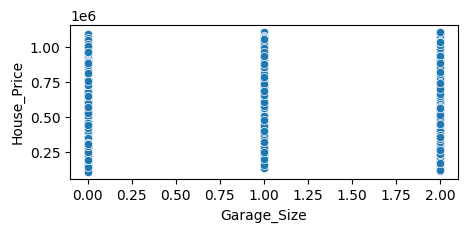

In [ ]:
plt.figure(figsize=(5,2))
sns.scatterplot(x="Garage_Size", y="House_Price", data=data)
plt.show()

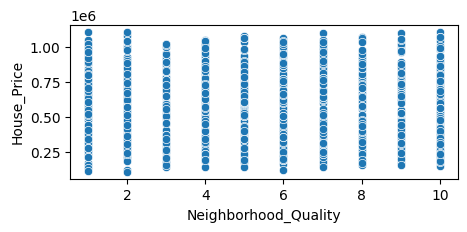

In [ ]:
plt.figure(figsize=(5,2))
sns.scatterplot(x="Neighborhood_Quality", y="House_Price", data=data)
plt.show()

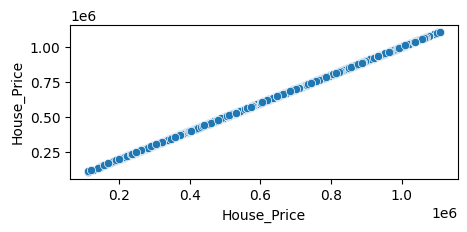

In [ ]:
plt.figure(figsize=(5,2))
sns.scatterplot(x="House_Price", y="House_Price", data=data)
plt.show()

# Generate Correlation Heatmap

In [ ]:
num_cols.corr()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
Square_Footage,1.000000,-0.043564,-0.031584,-0.022392,0.089479,0.030593,-0.008357,0.991261
Num_Bedrooms,-0.043564,1.000000,0.022848,-0.015820,-0.009355,0.113761,-0.049024,0.014633
Num_Bathrooms,-0.031584,0.022848,1.000000,-0.021063,0.034923,0.024846,0.017585,-0.001862
Year_Built,-0.022392,-0.015820,-0.021063,1.000000,-0.061050,-0.025485,-0.009549,0.051967
Lot_Size,0.089479,-0.009355,0.034923,-0.061050,1.000000,0.002436,0.037630,0.160412
Garage_Size,0.030593,0.113761,0.024846,-0.025485,0.002436,1.000000,-0.011287,0.052133
Neighborhood_Quality,-0.008357,-0.049024,0.017585,-0.009549,0.037630,-0.011287,1.000000,-0.007770
House_Price,0.991261,0.014633,-0.001862,0.051967,0.160412,0.052133,-0.007770,1.000000


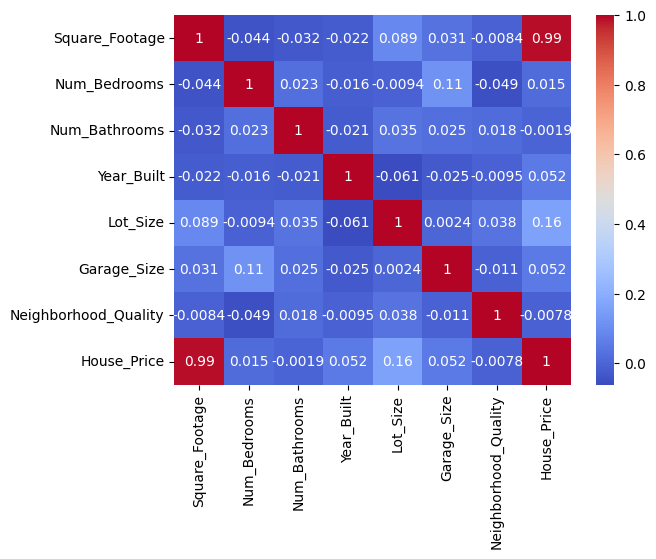

In [ ]:
sns.heatmap(data.corr(),annot=True, cmap="coolwarm")
plt.show()

#Detect and Handle Outliers

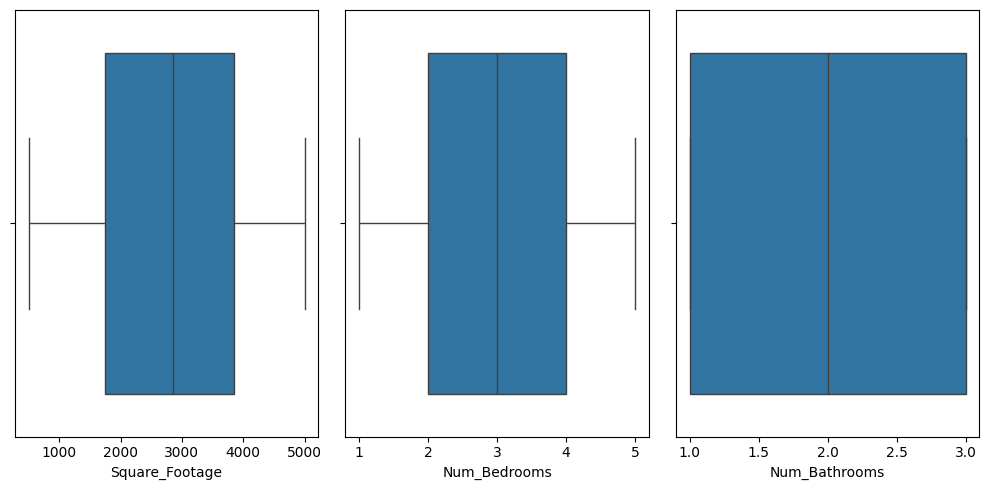

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(10,5))
sns.boxplot(data,x='Square_Footage',ax=ax[0])
sns.boxplot(data,x='Num_Bedrooms',ax=ax[1])
sns.boxplot(data,x='Num_Bathrooms',ax=ax[2])

plt.tight_layout()

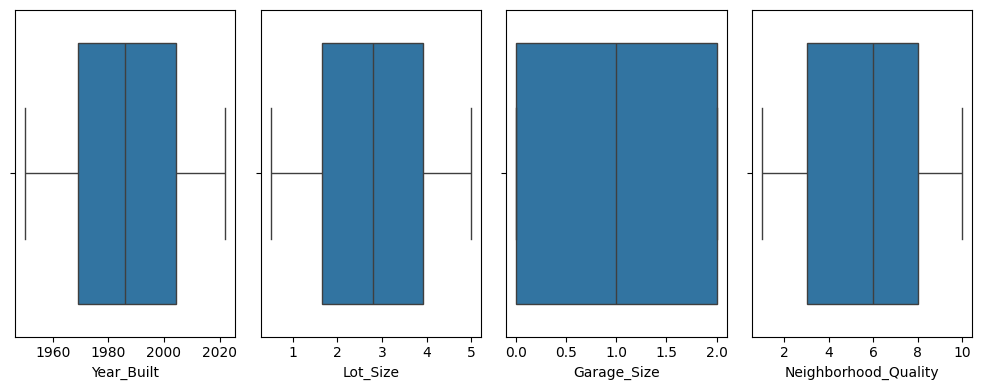

In [ ]:
fig,ax = plt.subplots(1,4,figsize=(10,4))

sns.boxplot(data,x='Year_Built',ax=ax[0])
sns.boxplot(data,x='Lot_Size',ax=ax[1])
sns.boxplot(data,x='Garage_Size',ax=ax[2])
sns.boxplot(data,x='Neighborhood_Quality',ax=ax[3])
plt.tight_layout()

# # Apply Log Transformation

In [ ]:

print(data['House_Price'].skew())
data.skew(numeric_only=True)

-0.06395513907654668


,0
Square_Footage,-0.066001
Num_Bedrooms,0.025884
Num_Bathrooms,0.049917
Year_Built,-0.021254
Lot_Size,-0.044288
Garage_Size,-0.040400
Neighborhood_Quality,-0.020445
House_Price,-0.063955


# Separate Features and Target Variable

In [ ]:
X = data.drop("House_Price", axis=1)
y = data["House_Price"]

# Perform Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



# Train Regression Models
● Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

● KNN regression

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Evaluate Models Using
#### ● MAE (Mean Absolute Error)
#### ● MSE (Mean Squared Error)
####● RMSE (Root Mean Squared Error)
####● MAPE
####● R2 Score
####● Adjusted r2

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)
    adj_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

    return mae, mse, rmse, mape, r2, adj_r2

## Evaluate Linear Regression

In [ ]:
lr_results = evaluate(y_test, y_pred_lr)


##  Evaluate KNN

In [ ]:
knn_results = evaluate(y_test, y_pred_knn)


## Display Results

In [ ]:
print("Linear Regression:", lr_results)
print("KNN Regression:", knn_results)

Linear Regression: (8174.583600006616, 101434798.50563587, np.float64(10071.484424137083), np.float64(1.6639061459737357), 0.9984263636823413, 0.9983689915249266)
KNN Regression: (69823.26478552072, 6986408437.145264, np.float64(83584.73806350812), np.float64(15.29885459008446), 0.8916144537313003, 0.8876628973569206)
